# MCDI504 · Machine Learning I
## Fase 1: Definición y orientación de la situación
### Proyecto IrisFlow: clasificación de especies Iris mediante variables morfológicas

**Institución:** Universidad Andrés Bello  
**Facultad:** Facultad de Ingeniería  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial  
**Asignatura:** MCDI504 · Machine Learning I  
**Docente:** Dr. David Ruete Zúñiga  
**Grupo:** 6  
**Integrantes:** Luis Díaz Giral · Gonzalo Bouldres · Eduardo Contreras  
**Fecha de entrega:** 08-08-2026

El notebook formaliza la definición analítica del problema, caracteriza la estructura y calidad de los datos, documenta las transformaciones de Fase 1 y justifica el enfoque de aprendizaje supervisado. No se entrenan ni evalúan modelos predictivos en esta fase.

## 1. Contexto y definición analítica del problema

**Contexto del caso.** IrisFlow es un escenario ficticio de recepción y clasificación de flores Iris. Como situación de análisis se plantea que la asignación manual de especie puede presentar inconsistencias cuando las diferencias morfológicas son pequeñas o la decisión depende exclusivamente de observación experta. El dataset Iris permite representar el problema mediante cuatro medidas cuantitativas de sépalo y pétalo y una etiqueta de especie conocida.

**Situación de análisis.** Cada observación contiene `Sepal.Length`, `Sepal.Width`, `Petal.Length` y `Petal.Width` como variables predictoras numéricas continuas, y `Species` como variable objetivo categórica nominal. Las categorías disponibles se obtienen al cargar el dataset.

**Problema analítico.** Establecer si la estructura, calidad y características exploratorias del dataset permiten formular de manera consistente un problema de Machine Learning supervisado para clasificar `Species` a partir de las medidas morfológicas disponibles.

**Pregunta analítica.** ¿Cómo permiten las variables morfológicas `Sepal.Length`, `Sepal.Width`, `Petal.Length` y `Petal.Width` estructurar un problema de aprendizaje supervisado para la clasificación multiclase de `Species` dentro del proceso KDD?

**Objetivo general.** Definir y justificar el enfoque metodológico inicial para la clasificación de especies Iris mediante la caracterización estructural, descriptiva y exploratoria del dataset y su articulación con las etapas del proceso KDD.

**Objetivos específicos.**

1. Verificar dimensiones, tipos de datos, completitud, combinaciones de valores coincidentes y distribución de `Species`.
2. Caracterizar las variables predictoras mediante estadística descriptiva y análisis de valores atípicos.
3. Examinar relaciones lineales entre variables numéricas mediante correlación de Pearson y valores p.
4. Aplicar una codificación temporal de `Species` únicamente como apoyo exploratorio, preservando su naturaleza nominal.
5. Normalizar las variables predictoras mediante Min-Max y verificar el rango resultante.
6. Justificar el aprendizaje supervisado de clasificación multiclase frente a alternativas metodológicas.

**Relación problema–datos–objetivo.** Las cuatro medidas morfológicas constituyen las variables de entrada; `Species` aporta la etiqueta conocida; y el propósito analítico es asignar una categoría de `Species`. Esta correspondencia entre predictores, etiqueta y salida esperada determina la naturaleza supervisada y multiclase del problema.

**Alcance de Fase 1.** Se desarrolla la definición del problema, el análisis exploratorio, la preparación inicial y la justificación metodológica. No se realiza partición entrenamiento/prueba, entrenamiento de modelos, ajuste de hiperparámetros ni evaluación predictiva.

La formulación del problema y la clasificación del aprendizaje siguen el marco docente del curso, mientras KDD estructura la secuencia de selección, preprocesamiento, transformación, minería de datos e interpretación (Ruete, 2026a, 2026b, 2026c).

## 2. Clasificación del tipo de aprendizaje

El proyecto corresponde a **aprendizaje supervisado de clasificación multiclase** porque existe una variable objetivo conocida y categórica para cada observación.

| Criterio | Evidencia en IrisFlow | Decisión metodológica |
|---|---|---|
| Variable objetivo | `Species` está disponible como etiqueta para cada observación | Aprendizaje supervisado |
| Naturaleza de `Species` | Categórica nominal con múltiples clases | Clasificación multiclase |
| Variables predictoras | Medidas morfológicas continuas | Entradas numéricas |
| Resultado analítico | Asignar una observación a una especie | Predicción de clase |

La correspondencia entre datos etiquetados, variable objetivo nominal y propósito de asignación de clase determina el enfoque seleccionado (Ruete, 2026b).


## 3. Relación entre Machine Learning y KDD

KDD organiza el proceso de descubrimiento de conocimiento; Machine Learning se ubica principalmente en la etapa de minería de datos y se articula con selección, preprocesamiento, transformación e interpretación (Ruete, 2026c; Fayyad et al., 1996).

| Etapa KDD | Aplicación en IrisFlow | Función en Fase 1 |
|---|---|---|
| Selección | Dataset Iris, predictores morfológicos y `Species` | Delimita variables de entrada y variable objetivo |
| Preprocesamiento | Tipos de datos, faltantes, combinaciones de valores repetidas, distribución de clases y valores atípicos | Caracteriza la calidad y estructura de los datos |
| Transformación | Codificación exploratoria de `Species` y normalización de predictores | Genera representaciones numéricas para el análisis de Fase 1 |
| Modelamiento / minería de datos | Clasificación supervisada multiclase | Define el enfoque de aprendizaje; no ejecuta entrenamiento en Fase 1 |
| Interpretación y evaluación | Síntesis de la evidencia exploratoria obtenida | Relaciona los resultados descriptivos con el problema analítico |

**Flujo computacional de Fase 1:** selección → control de integridad → análisis descriptivo → transformación exploratoria → correlación y valores p → normalización → comparación metodológica.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

cwd = Path.cwd()
if (cwd / "Semana1").exists():
    semana1_dir = cwd / "Semana1"
elif cwd.name == "Semana1":
    semana1_dir = cwd
elif cwd.name == "notebook" and cwd.parent.name == "Semana1":
    semana1_dir = cwd.parent
else:
    semana1_dir = cwd

data_dir = semana1_dir / "data"
outputs_dir = semana1_dir / "outputs"
figures_dir = semana1_dir / "figures"

for directorio in (data_dir, outputs_dir, figures_dir):
    directorio.mkdir(parents=True, exist_ok=True)


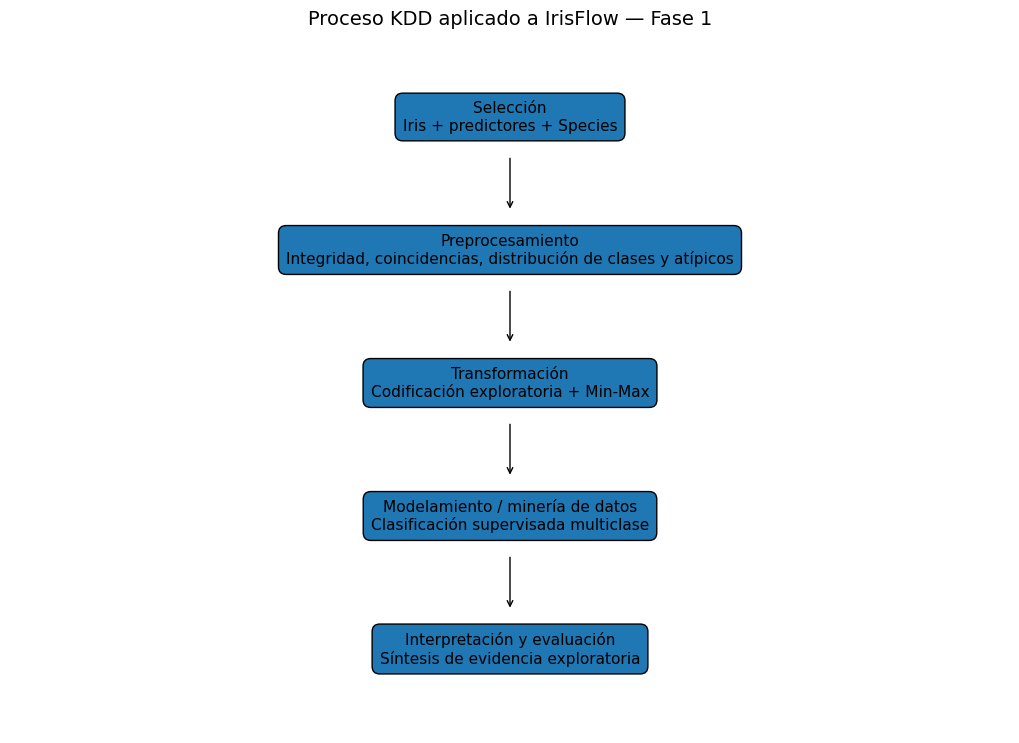

,Etapa KDD,Aplicación en IrisFlow,Función en Fase 1
0,Selección,Iris + predictores + Species,Delimita entradas y objetivo
1,Preprocesamiento,"Integridad, coincidencias, distribución de cla...",Caracteriza calidad y estructura de los datos
2,Transformación,Codificación exploratoria + Min-Max,Genera representaciones numéricas para el anál...
3,Modelamiento / minería de datos,Clasificación supervisada multiclase,Define el enfoque de aprendizaje sin ejecutar ...
4,Interpretación y evaluación,Síntesis de evidencia exploratoria,Relaciona la evidencia obtenida con el problem...


In [2]:
etapas = [
    "Selección",
    "Preprocesamiento",
    "Transformación",
    "Modelamiento / minería de datos",
    "Interpretación y evaluación"
]

detalle = [
    "Iris + predictores + Species",
    "Integridad, coincidencias, distribución de clases y atípicos",
    "Codificación exploratoria + Min-Max",
    "Clasificación supervisada multiclase",
    "Síntesis de evidencia exploratoria"
]

funcion_fase1 = [
    "Delimita entradas y objetivo",
    "Caracteriza calidad y estructura de los datos",
    "Genera representaciones numéricas para el análisis",
    "Define el enfoque de aprendizaje sin ejecutar entrenamiento",
    "Relaciona la evidencia obtenida con el problema analítico"
]

kdd_aplicado = pd.DataFrame({
    "Etapa KDD": etapas,
    "Aplicación en IrisFlow": detalle,
    "Función en Fase 1": funcion_fase1
})
kdd_aplicado.to_csv(outputs_dir / "kdd_aplicado.csv", index=False, encoding="utf-8-sig")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_axes([0, 0, 1, 1])
ax.axis("off")
posiciones = np.linspace(0.88, 0.12, len(etapas))

for i, (etapa, texto, y) in enumerate(zip(etapas, detalle, posiciones)):
    ax.text(
        0.5, y, f"{etapa}\n{texto}",
        ha="center", va="center", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5")
    )
    if i < len(etapas) - 1:
        ax.annotate(
            "",
            xy=(0.5, posiciones[i + 1] + 0.055),
            xytext=(0.5, y - 0.055),
            arrowprops=dict(arrowstyle="->")
        )

ax.set_title("Proceso KDD aplicado a IrisFlow — Fase 1", fontsize=14)
fig.savefig(figures_dir / "flujo_kdd.png", dpi=300, bbox_inches="tight")
plt.show()

kdd_aplicado


## 4. Carga y estructura del dataset

El dataset se carga desde `scikit-learn` mediante `load_iris()`. La construcción del `DataFrame` conserva los predictores numéricos y `Species` como variable categórica, diferenciando variables de entrada y variable objetivo (pandas development team, s. f.; scikit-learn developers, s. f.; Pedregosa et al., 2011).

In [3]:
iris = load_iris()

predictores = ["Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width"]

bbdd1 = pd.DataFrame(iris.data, columns=predictores)
bbdd1["Species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
bbdd1.to_csv(data_dir / "iris_original.csv", index=False, encoding="utf-8-sig")

print(f"Dimensiones: {bbdd1.shape[0]} observaciones x {bbdd1.shape[1]} variables")
bbdd1.head()


Dimensiones: 150 observaciones x 5 variables


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 4.1 Diccionario de variables

| Variable | Rol | Tipo de dato | Unidad / escala | Interpretación |
|---|---|---|---|---|
| `Sepal.Length` | Predictora | Numérica continua | cm | Longitud del sépalo |
| `Sepal.Width` | Predictora | Numérica continua | cm | Ancho del sépalo |
| `Petal.Length` | Predictora | Numérica continua | cm | Longitud del pétalo |
| `Petal.Width` | Predictora | Numérica continua | cm | Ancho del pétalo |
| `Species` | Objetivo | Categórica nominal | No aplica | Especie de la observación |

Las unidades corresponden a la descripción del dataset Iris distribuido por `scikit-learn` (scikit-learn developers, s. f.).


## 5. Control de integridad y distribución de la variable objetivo

El control inicial obtiene dimensiones, completitud, tipos de datos, combinaciones de valores repetidas y distribución de clases para caracterizar la integridad del dataset.

In [4]:
control_integridad = pd.DataFrame({
    "Indicador": [
        "Observaciones",
        "Variables",
        "Valores faltantes",
        "Registros con combinación completa repetida respecto de una fila previa",
        "Clases de Species"
    ],
    "Resultado": [
        len(bbdd1),
        bbdd1.shape[1],
        int(bbdd1.isna().sum().sum()),
        int(bbdd1.duplicated().sum()),
        int(bbdd1["Species"].nunique())
    ]
})
control_integridad.to_csv(outputs_dir / "control_integridad.csv", index=False, encoding="utf-8-sig")

control_integridad


,Indicador,Resultado
0,Observaciones,150
1,Variables,5
2,Valores faltantes,0
3,Registros con combinación completa repetida re...,1
4,Clases de Species,3


In [5]:
estructura = pd.DataFrame({
    "Tipo": bbdd1.dtypes.astype(str),
    "No nulos": bbdd1.notna().sum(),
    "Valores únicos": bbdd1.nunique()
})
estructura.to_csv(outputs_dir / "estructura_variables.csv", encoding="utf-8-sig", index_label="Variable")

estructura


,Tipo,No nulos,Valores únicos
Sepal.Length,float64,150,35
Sepal.Width,float64,150,23
Petal.Length,float64,150,43
Petal.Width,float64,150,22
Species,category,150,3


In [6]:
coincidencias_exactas = bbdd1[bbdd1.duplicated(keep=False)]
coincidencias_exactas.to_csv(outputs_dir / "registros_coincidentes.csv", encoding="utf-8-sig", index_label="Fila")

coincidencias_exactas


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [7]:
distribucion_clases = (
    bbdd1["Species"]
    .value_counts()
    .sort_index()
    .rename("Frecuencia")
    .to_frame()
)

distribucion_clases["Porcentaje"] = (
    distribucion_clases["Frecuencia"] / len(bbdd1) * 100
).round(2)

distribucion_clases.to_csv(outputs_dir / "distribucion_clases.csv", encoding="utf-8-sig")
distribucion_clases


,Frecuencia,Porcentaje
Species,,
setosa,50,33.33
versicolor,50,33.33
virginica,50,33.33


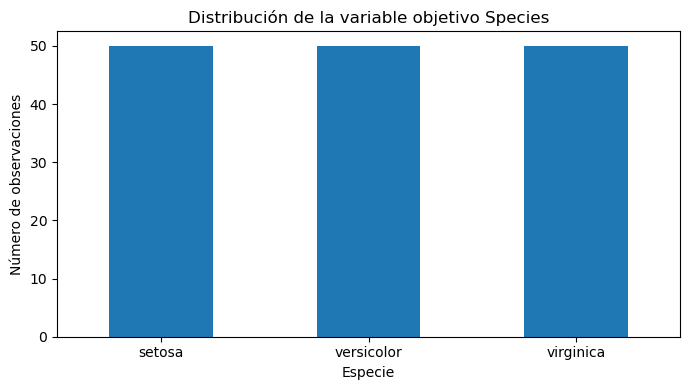

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
bbdd1["Species"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribución de la variable objetivo Species")
ax.set_xlabel("Especie")
ax.set_ylabel("Número de observaciones")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(figures_dir / "distribucion_species.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Estadística descriptiva y revisión de valores atípicos

La estadística descriptiva caracteriza tendencia central, dispersión y rango. El boxplot y el criterio de Tukey (`1.5 × IQR`) se utilizan para identificar observaciones atípicas relativas; su detección no implica eliminación automática.

In [9]:
resumen_descriptivo = bbdd1[predictores].describe().T
resumen_descriptivo = resumen_descriptivo[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
].round(3)
resumen_descriptivo.to_csv(outputs_dir / "resumen_descriptivo.csv", encoding="utf-8-sig", index_label="Variable")

resumen_descriptivo


,count,mean,std,min,25%,50%,75%,max
Sepal.Length,150.0,5.843,0.828,4.3,5.1,5.80,6.4,7.9
Sepal.Width,150.0,3.057,0.436,2.0,2.8,3.00,3.3,4.4
Petal.Length,150.0,3.758,1.765,1.0,1.6,4.35,5.1,6.9
Petal.Width,150.0,1.199,0.762,0.1,0.3,1.30,1.8,2.5


In [10]:
revision_atipicos = []

for variable in predictores:
    q1 = bbdd1[variable].quantile(0.25)
    q3 = bbdd1[variable].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (bbdd1[variable] < limite_inferior) | (bbdd1[variable] > limite_superior)

    revision_atipicos.append({
        "Variable": variable,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "N atípicos": int(mascara.sum())
    })

atipicos_tukey = pd.DataFrame(revision_atipicos).set_index("Variable").round(3)
atipicos_tukey.to_csv(outputs_dir / "atipicos_tukey.csv", encoding="utf-8-sig")
atipicos_tukey


,Límite inferior,Límite superior,N atípicos
Variable,,,
Sepal.Length,3.15,8.35,0
Sepal.Width,2.05,4.05,4
Petal.Length,-3.65,10.35,0
Petal.Width,-1.95,4.05,0


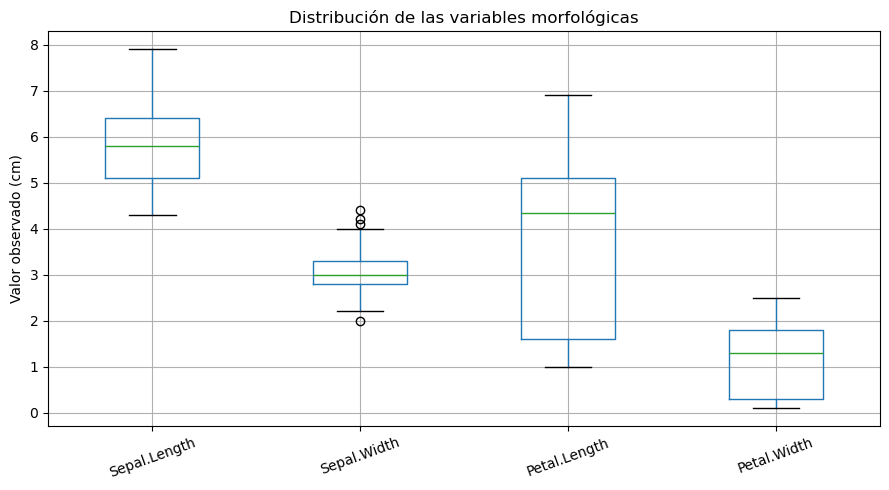

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
bbdd1[predictores].boxplot(ax=ax)
ax.set_title("Distribución de las variables morfológicas")
ax.set_ylabel("Valor observado (cm)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(figures_dir / "boxplot_variables.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Codificación temporal de `Species`

Para el análisis exploratorio se crea una copia de la base y se asigna a cada categoría de `Species` un identificador numérico temporal. Esta codificación no transforma a `Species` en una variable continua u ordinal.

In [12]:
bbdd2 = bbdd1.copy()
bbdd2["Species"] = bbdd2["Species"].cat.codes + 1

codificacion_species = pd.DataFrame({
    "Código temporal": range(1, len(iris.target_names) + 1),
    "Species": iris.target_names
})
codificacion_species.to_csv(outputs_dir / "codificacion_species.csv", index=False, encoding="utf-8-sig")

codificacion_species


,Código temporal,Species
0,1,setosa
1,2,versicolor
2,3,virginica


## 8. Correlación de Pearson

El análisis principal de Pearson se realiza entre las variables predictoras continuas. De manera separada se calcula la correlación con `Species` codificada únicamente como señal exploratoria, sin atribuirle interpretación ordinal o inferencial.

In [13]:
matriz_correlacion = bbdd1[predictores].corr(method="pearson")
matriz_correlacion.to_csv(outputs_dir / "correlacion_predictores.csv", encoding="utf-8-sig", index_label="Variable")
matriz_correlacion.round(3)


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.000,-0.118,0.872,0.818
Sepal.Width,-0.118,1.000,-0.428,-0.366
Petal.Length,0.872,-0.428,1.000,0.963
Petal.Width,0.818,-0.366,0.963,1.000


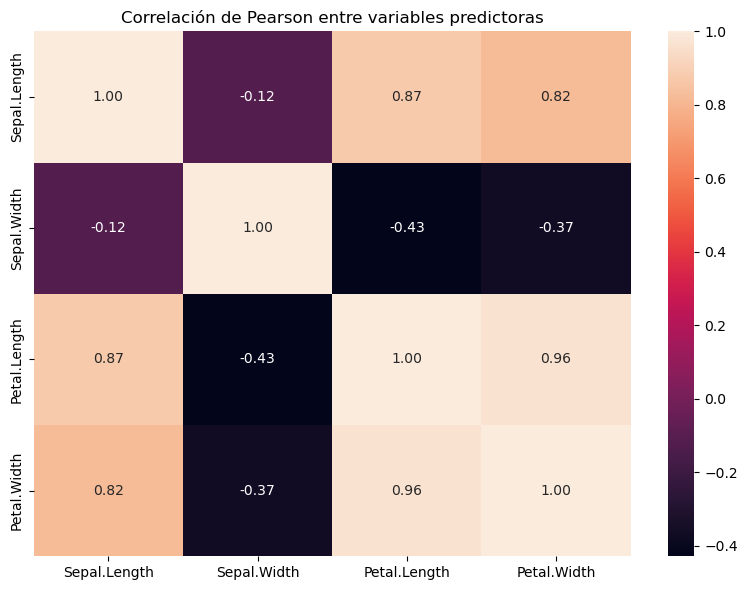

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlación de Pearson entre variables predictoras")
fig.tight_layout()
fig.savefig(figures_dir / "correlacion_pearson.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
correlacion_species_exploratoria = (
    bbdd2[predictores + ["Species"]]
    .corr(method="pearson")
    .loc[predictores, ["Species"]]
    .rename(columns={"Species": "r con Species codificada"})
    .round(3)
)
correlacion_species_exploratoria.to_csv(
    outputs_dir / "correlacion_species_exploratoria.csv", encoding="utf-8-sig", index_label="Variable"
)

correlacion_species_exploratoria


,r con Species codificada
Sepal.Length,0.783
Sepal.Width,-0.427
Petal.Length,0.949
Petal.Width,0.957


## 9. Valores p asociados a Pearson

Los valores p se calculan únicamente entre variables predictoras continuas. Para cada par se contrasta `H₀: ρ = 0` frente a `H₁: ρ ≠ 0`, utilizando `α = 0.05`. Los resultados se emplean como evidencia exploratoria de asociación lineal y no como mecanismo automático de selección de variables.


In [16]:
def matriz_pvalores(df):
    columnas = df.columns
    resultado = pd.DataFrame(np.nan, index=columnas, columns=columnas)

    for i, col_1 in enumerate(columnas):
        for j, col_2 in enumerate(columnas):
            if i != j:
                resultado.loc[col_1, col_2] = pearsonr(df[col_1], df[col_2]).pvalue

    return resultado

pvalores = matriz_pvalores(bbdd1[predictores])
pvalores.to_csv(outputs_dir / "pvalores_predictores.csv", encoding="utf-8-sig", index_label="Variable")
pvalores


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,NaN,1.518983e-01,1.038667e-47,2.325498e-37
Sepal.Width,1.518983e-01,NaN,4.513314e-08,4.073229e-06
Petal.Length,1.038667e-47,4.513314e-08,NaN,4.675004e-86
Petal.Width,2.325498e-37,4.073229e-06,4.675004e-86,NaN


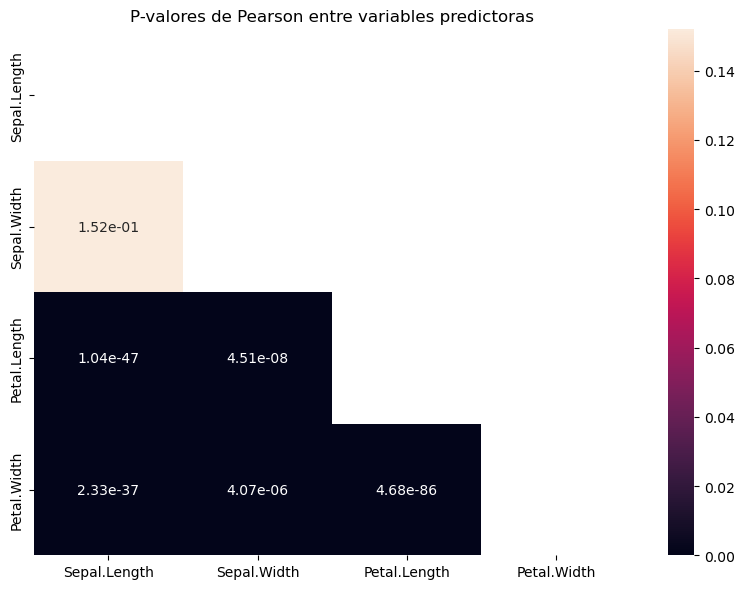

In [17]:
mascara = np.triu(np.ones_like(pvalores, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pvalores, annot=True, fmt=".2e", mask=mascara, ax=ax)
ax.set_title("P-valores de Pearson entre variables predictoras")
fig.tight_layout()
fig.savefig(figures_dir / "pvalores_pearson.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
p_sepal = pvalores.loc["Sepal.Length", "Sepal.Width"]

print(f"p(Sepal.Length, Sepal.Width) = {p_sepal:.6f}")
print(f"Decisión con α = 0.05: {'no rechazar H0' if p_sepal >= 0.05 else 'rechazar H0'}")

p(Sepal.Length, Sepal.Width) = 0.151898
Decisión con α = 0.05: no rechazar H0


## 10. Normalización Min-Max

Se normalizan exclusivamente las variables predictoras. `Species` conserva su tipo categórico. `MinMaxScaler` transforma cada predictor al intervalo `[0, 1]` según los mínimos y máximos observados (scikit-learn developers, s. f.).

In [19]:
scaler = MinMaxScaler()

bbdd_norm = pd.DataFrame(
    scaler.fit_transform(bbdd1[predictores]),
    columns=predictores,
    index=bbdd1.index
)

bbdd_norm_completa = pd.concat([bbdd_norm, bbdd1[["Species"]]], axis=1)
bbdd_norm_completa.to_csv(outputs_dir / "iris_normalizado.csv", index=False, encoding="utf-8-sig")
bbdd_norm_completa.head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,0.222222,0.625000,0.067797,0.041667,setosa
1,0.166667,0.416667,0.067797,0.041667,setosa
2,0.111111,0.500000,0.050847,0.041667,setosa
3,0.083333,0.458333,0.084746,0.041667,setosa
4,0.194444,0.666667,0.067797,0.041667,setosa


In [20]:
verificacion_normalizacion = pd.DataFrame({
    "Mínimo": bbdd_norm.min(),
    "Máximo": bbdd_norm.max()
}).round(6)
verificacion_normalizacion.to_csv(
    outputs_dir / "verificacion_normalizacion.csv", encoding="utf-8-sig", index_label="Variable"
)

verificacion_normalizacion


,Mínimo,Máximo
Sepal.Length,0.0,1.0
Sepal.Width,0.0,1.0
Petal.Length,0.0,1.0
Petal.Width,0.0,1.0


## 11. Comparación de enfoques y justificación de descarte

La comparación se realiza según disponibilidad de etiqueta, naturaleza de la señal y objetivo analítico, de acuerdo con los tres tipos de aprendizaje considerados en la actividad (Ruete, 2026b).


In [21]:
comparacion_enfoques = pd.DataFrame([
    {
        "Enfoque": "Supervisado",
        "Definición operativa": "Aprende una relación entre predictores y una salida conocida",
        "Dato o señal requerida": "Observaciones con etiqueta",
        "Ejemplo de uso": "Clasificar Species a partir de medidas morfológicas",
        "Evaluación para IrisFlow": "Seleccionado: existe etiqueta y la salida es categórica"
    },
    {
        "Enfoque": "No supervisado",
        "Definición operativa": "Busca estructura sin utilizar una etiqueta objetivo",
        "Dato o señal requerida": "Observaciones sin etiqueta",
        "Ejemplo de uso": "Agrupar flores por similitud morfológica ignorando Species",
        "Evaluación para IrisFlow": "Complementario: no responde al objetivo predictivo principal"
    },
    {
        "Enfoque": "Por refuerzo",
        "Definición operativa": "Aprende una política mediante interacción y recompensas",
        "Dato o señal requerida": "Estados, acciones y recompensa",
        "Ejemplo de uso": "Optimizar una secuencia de decisiones en un entorno dinámico",
        "Evaluación para IrisFlow": "Descartado: el dataset es estático y no contiene interacción ni recompensas"
    }
])
comparacion_enfoques.to_csv(outputs_dir / "comparacion_enfoques.csv", index=False, encoding="utf-8-sig")
comparacion_enfoques


,Enfoque,Definición operativa,Dato o señal requerida,Ejemplo de uso,Evaluación para IrisFlow
0,Supervisado,Aprende una relación entre predictores y una s...,Observaciones con etiqueta,Clasificar Species a partir de medidas morfoló...,Seleccionado: existe etiqueta y la salida es c...
1,No supervisado,Busca estructura sin utilizar una etiqueta obj...,Observaciones sin etiqueta,Agrupar flores por similitud morfológica ignor...,Complementario: no responde al objetivo predic...
2,Por refuerzo,Aprende una política mediante interacción y re...,"Estados, acciones y recompensa",Optimizar una secuencia de decisiones en un en...,Descartado: el dataset es estático y no contie...


La clasificación supervisada multiclase mantiene correspondencia directa entre la información disponible (`Species`) y el resultado requerido. El aprendizaje no supervisado puede complementar una exploración de estructura si se omite la etiqueta, pero no sustituye el objetivo de clasificación. El aprendizaje por refuerzo no corresponde porque no existen estados, acciones ni recompensas. La regresión tampoco corresponde porque la variable objetivo no es continua.


## 12. Referencias técnicas

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine, 17*(3), 37–54.
- pandas development team. (s. f.). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Ruete, D. (2026a). *Fase 1: Estadística descriptiva, correlación y normalización de datos* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026b). *Introducción al Machine Learning* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026c). *Relación entre ML y Metodología KDD* [Apunte]. Universidad Andrés Bello.
- scikit-learn developers. (s. f.). *scikit-learn documentation*. https://scikit-learn.org/stable/documentation.html


## 13. Inventario de evidencia generada

La celda final lista los archivos generados por la ejecución.


In [22]:
archivos_csv = sorted(p.name for p in outputs_dir.glob("*.csv"))
archivos_figuras = sorted(p.name for p in figures_dir.glob("*.png"))
archivo_datos = data_dir / "iris_original.csv"

evidencia_generada = {
    "dataset_exportado": archivo_datos.exists(),
    "archivos_csv": archivos_csv,
    "figuras_png": archivos_figuras
}

evidencia_generada


{'dataset_exportado': True,
 'archivos_csv': ['atipicos_tukey.csv',
  'codificacion_species.csv',
  'comparacion_enfoques.csv',
  'control_integridad.csv',
  'correlacion_predictores.csv',
  'correlacion_species_exploratoria.csv',
  'distribucion_clases.csv',
  'estructura_variables.csv',
  'iris_normalizado.csv',
  'kdd_aplicado.csv',
  'pvalores_predictores.csv',
  'registros_coincidentes.csv',
  'resumen_descriptivo.csv',
  'verificacion_normalizacion.csv'],
 'figuras_png': ['boxplot_variables.png',
  'correlacion_pearson.png',
  'distribucion_species.png',
  'flujo_kdd.png',
  'pvalores_pearson.png']}